In [17]:
import os
print(os.getcwd())

/content


In [18]:
image_dir_path="/content/Sudoku_Dataset"
image1="/sudoku1.png"
image2="/sudoku2.jpg"

In [19]:
import cv2
import imutils
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(image, height):
    ##Resizing the image for smaller pixel sizes
  image=imutils.resize(image,height=height)
  ## Step 1: Converting to gray scale
  gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
  ## Step 1.1 : Histogram equalization to normalize contrast across the whole image
  gray=cv2.equalizeHist(gray)
  plt.subplot(1,4,1); plt.imshow(gray, cmap='gray'); plt.title("Gray")
  ## Step 2: Gaussing Blurring for noise reduction
  blurred = cv2.GaussianBlur(gray,(7,7),3,cv2.BORDER_REFLECT_101)
  plt.subplot(1,4,2); plt.imshow(blurred, cmap='gray'); plt.title("Blurred")
  ## Step 3: Adaptive Thresholding
  ## https://docs.opencv.org/3.4/d7/d4d/tutorial_py_thresholding.html
  thresh= cv2.adaptiveThreshold(
      blurred,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11,3
  )
  plt.subplot(1,4,3); plt.imshow(thresh, cmap='gray'); plt.title("Threshold")
  ## Step 4: Invert to make grid lines white
  thresh=cv2.bitwise_not(thresh)

  ## Step 5: Morphological op
  kernel=cv2.getStructuringElement(cv2.MORPH_RECT,(3,3))
  processed=cv2.morphologyEx(thresh,cv2.MORPH_CLOSE,kernel)

  plt.subplot(1,4,4); plt.imshow(processed, cmap='gray'); plt.title("Edges")
  return image,processed

def preprocess(image_path,height=800):
  image=cv2.imread(image_path)
  return preprocess_image(image,height)



/content/Sudoku_Dataset/sudoku1.png


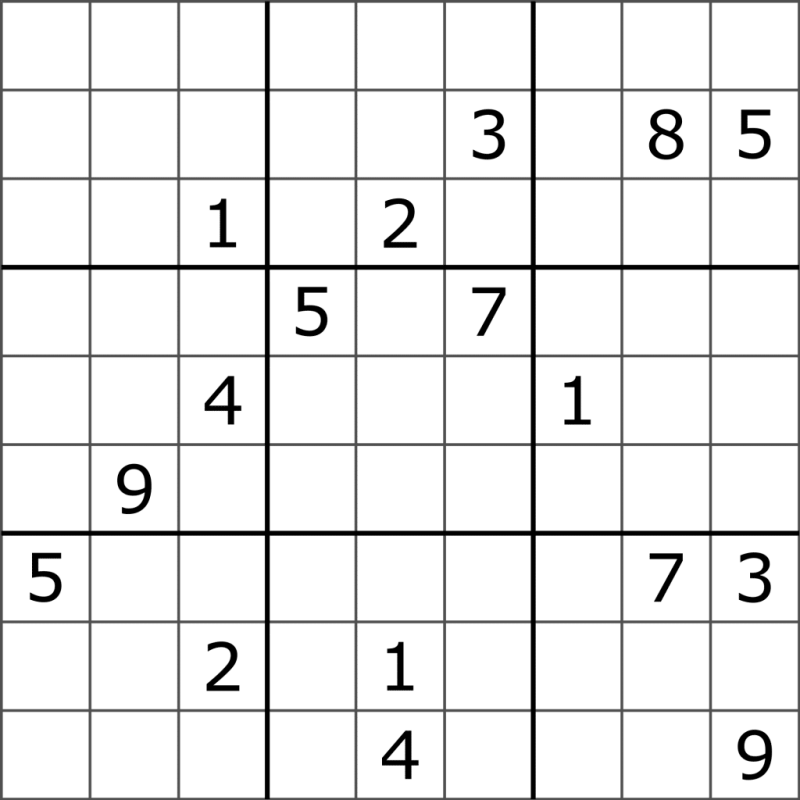

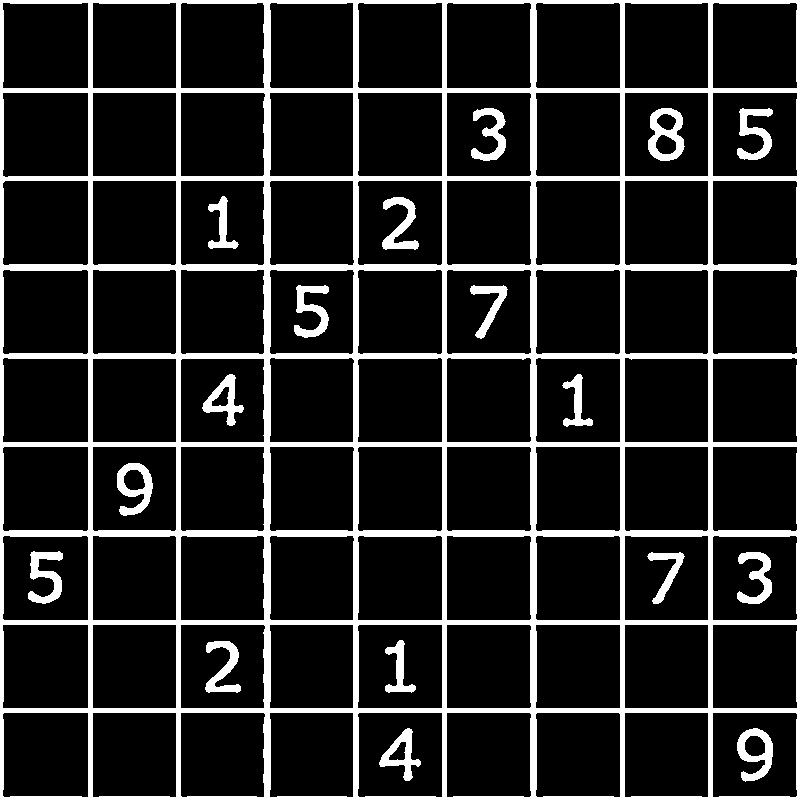

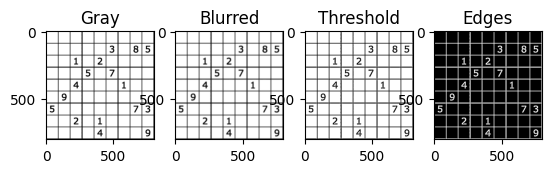

In [20]:
from google.colab.patches import cv2_imshow
image_path=image_dir_path+image1
print(image_path)
# Check if the file exists
if not os.path.exists(image_path):
    print("❌ Error: Image file not found at", image_path)
original,processed=preprocess(image_path)
cv2_imshow(original)
cv2_imshow(processed)

/content/Sudoku_Dataset/sudoku2.jpg


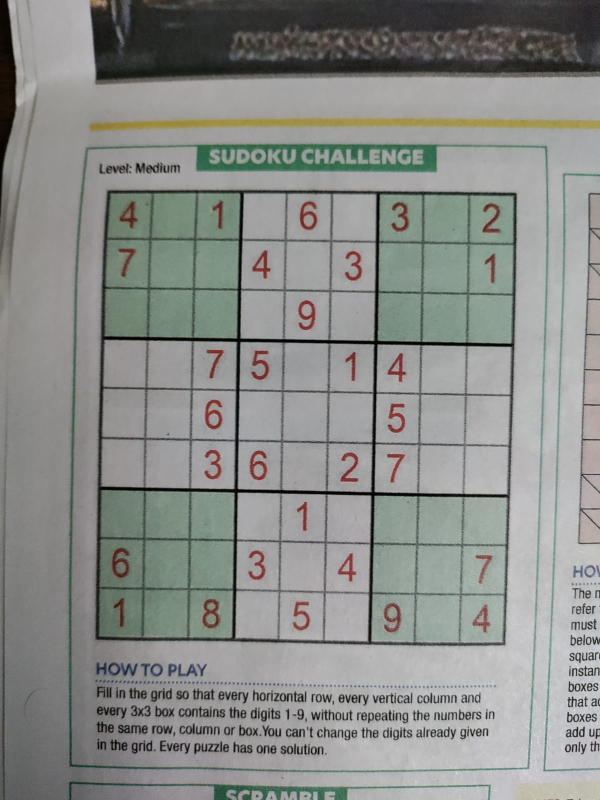

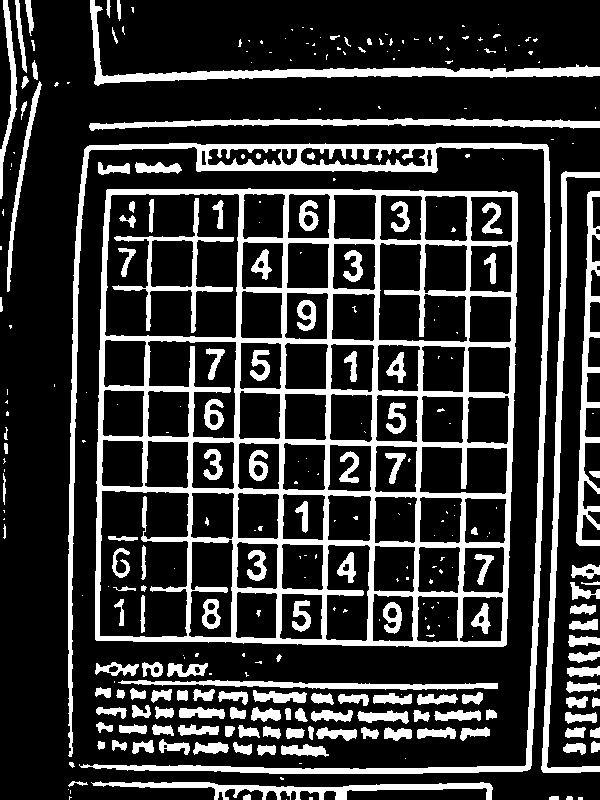

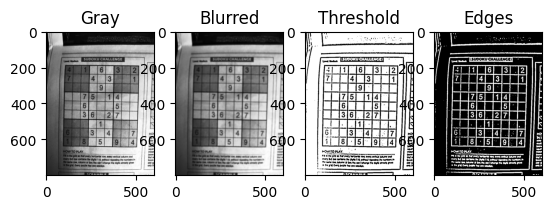

In [21]:
from google.colab.patches import cv2_imshow
image_path=image_dir_path+image2
print(image_path)
# Check if the file exists
if not os.path.exists(image_path):
    print("❌ Error: Image file not found at", image_path)
original,processed=preprocess(image_path)
cv2_imshow(original)
cv2_imshow(processed)



In [22]:
def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left has smallest sum
    rect[2] = pts[np.argmax(s)]   # bottom-right has largest sum

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right has smallest difference
    rect[3] = pts[np.argmax(diff)]  # bottom-left has largest difference
    return rect



In [23]:
def detect_sudoku_grid(processed,original_image):
    contours = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = imutils.grab_contours(contours)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    sudoku_contour = None
    for c in contours:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.03 * peri, True)
        if len(approx) == 4:
            sudoku_contour = approx
            break

    if sudoku_contour is None:
        print("❌ Sudoku grid not found.")
        return None, None

    # Order corners
    sudoku_contour = sudoku_contour.reshape(4, 2)
    rect = order_points(sudoku_contour)

    # Draw contour for visualization
    debug_img = original_image.copy()
    cv2.drawContours(debug_img, [sudoku_contour.astype(int)], -1, (0, 255, 0), 3)

    return rect, debug_img



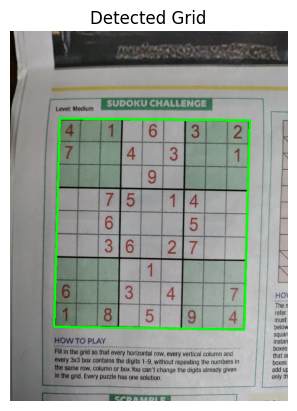

In [24]:
rect, debug = detect_sudoku_grid(processed, original)
plt.imshow(cv2.cvtColor(debug, cv2.COLOR_BGR2RGB))
plt.title("Detected Grid")
plt.axis('off')
plt.show()



In [25]:
def wrap_sudoku(order_points,original_image):
  output_size=450
  dst = np.array([
        [0, 0],
        [output_size - 1, 0],
        [output_size - 1, output_size - 1],
        [0, output_size - 1]
    ], dtype="float32")
  M=cv2.getPerspectiveTransform(rect,dst)
  warped=cv2.warpPerspective(original_image,M,(output_size,output_size))
  return warped

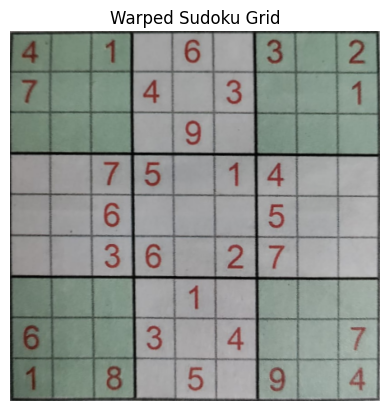

In [26]:
warped_image=wrap_sudoku(rect,original)
plt.imshow(cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB))
plt.title("Warped Sudoku Grid")
plt.axis("off")
plt.show()

In [27]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow  # ✅ Required for Colab display

def preprocess_wrapped_sudoku(warped, show_steps=False):
    """
    Preprocess a warped Sudoku image for digit extraction.

    Steps:
    1. Convert to grayscale
    2. Histogram equalization
    3. Gaussian blur
    4. Adaptive thresholding (binary inverse)

    Parameters:
        warped (np.ndarray): Warped Sudoku image (top-down view)
        show_steps (bool): If True, displays intermediate steps

    Returns:
        thresh (np.ndarray): Final preprocessed (binary) image
        steps (dict): Dictionary of intermediate results
    """

    steps = {}

    # 1️⃣ Grayscale conversion
    gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY) if len(warped.shape) == 3 else warped
    steps["gray"] = gray

    # 2️⃣ Histogram equalization for better contrast
    gray_eq = cv2.equalizeHist(gray)
    steps["equalized"] = gray_eq

    # 3️⃣ Gaussian blur to reduce small noise
    blurred = cv2.GaussianBlur(gray,(7,7),3,cv2.BORDER_REFLECT_101)
    steps["blurred"] = blurred

    # 4️⃣ Adaptive threshold (invert so digits are white)
    thresh = cv2.adaptiveThreshold(
      blurred,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,11,1
    )
    steps["thresh"] = thresh

    # Optional visualization
    if show_steps:
        titles = ["Gray", "Equalized", "Blurred", "Thresholded"]
        images = [steps[k] for k in ["gray", "equalized", "blurred", "thresh"]]
        for title, img in zip(titles, images):
            print(f"📷 {title}")
            cv2_imshow(img)  # ✅ Show image in Colab

    return thresh, steps


In [28]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow  # ✅ required in Colab

def split_into_cells(preprocessed_img, grid_size=9, visualize=False):
    """
    Splits a preprocessed Sudoku image into 81 individual cell images (9x9 grid).

    Parameters:
        preprocessed_img (np.ndarray): Binary (thresholded) top-down Sudoku image
        grid_size (int): Number of rows and columns (default 9)
        visualize (bool): If True, shows each cell in a grid visualization

    Returns:
        cells (list): List of 81 cell images (each as np.ndarray)
    """

    h, w = preprocessed_img.shape[:2]
    cell_h, cell_w = h // grid_size, w // grid_size

    cells = []

    for i in range(grid_size):
        for j in range(grid_size):
            # Crop each cell
            y1, y2 = i * cell_h, (i + 1) * cell_h
            x1, x2 = j * cell_w, (j + 1) * cell_w

            cell = preprocessed_img[y1:y2, x1:x2]

            # Optional cleanup (remove extra border pixels)
            margin = 2
            cell = cell[margin:-margin, margin:-margin] if cell.shape[0] > 4 and cell.shape[1] > 4 else cell

            cells.append(cell)

    # ✅ Visualization grid (only if requested)
    if visualize:
        cell_grid = np.zeros((h, w), dtype=np.uint8)
        idx = 0
        for i in range(grid_size):
            for j in range(grid_size):
                y1, y2 = i * cell_h, (i + 1) * cell_h
                x1, x2 = j * cell_w, (j + 1) * cell_w
                cell_resized = cv2.resize(cells[idx], (cell_w, cell_h))
                cell_grid[y1:y2, x1:x2] = cell_resized
                idx += 1
        cv2_imshow(cell_grid)  # ✅ works in Colab

    return cells


📷 Gray


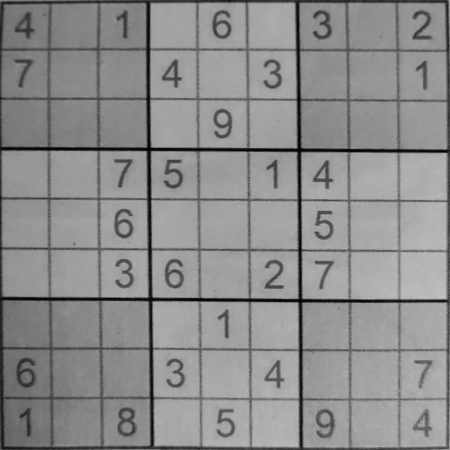

📷 Equalized


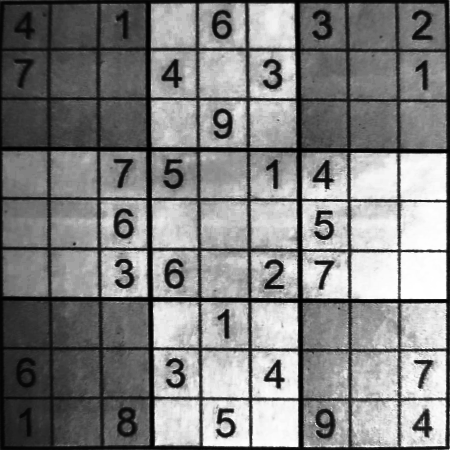

📷 Blurred


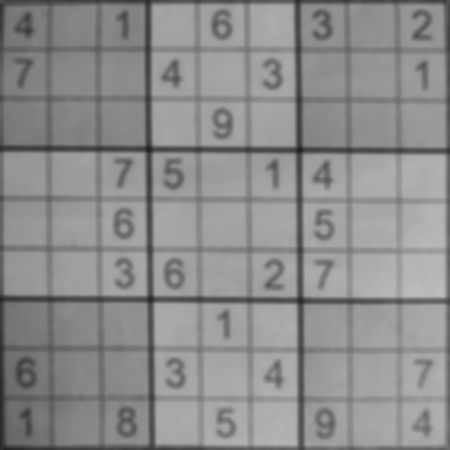

📷 Thresholded


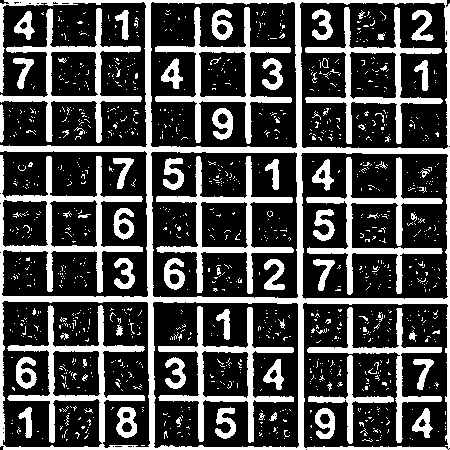

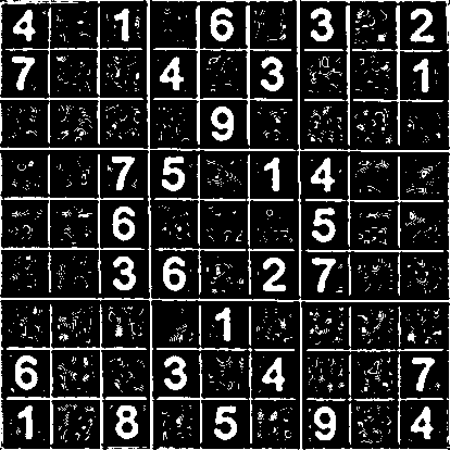

Extracted 81 cells


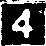

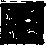

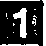

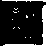

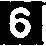

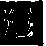

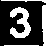

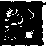

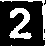

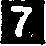

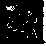

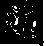

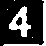

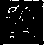

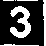

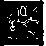

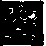

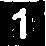

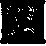

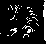

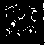

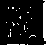

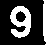

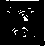

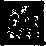

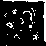

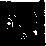

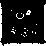

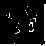

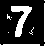

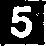

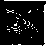

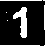

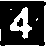

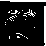

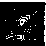

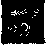

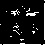

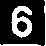

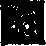

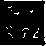

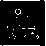

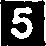

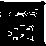

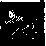

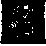

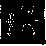

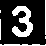

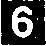

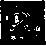

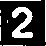

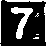

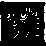

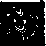

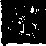

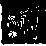

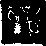

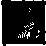

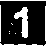

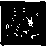

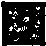

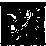

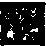

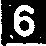

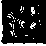

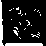

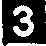

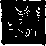

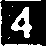

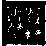

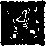

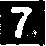

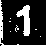

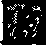

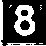

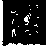

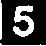

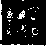

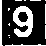

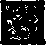

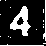

In [29]:
# Suppose `warped` is your top-down Sudoku image
thresh, steps = preprocess_wrapped_sudoku(warped_image, show_steps=True)

# Now split 'thresh' into 81 cells
cells = split_into_cells(thresh,visualize=True)
print(f"Extracted {len(cells)} cells")

# Example: visualize one cell
for cell in cells:
  cv2_imshow(cell)

In [30]:

def detect_digit_debug_with_median_and_close(cell, idx=None):
    if len(cell.shape) == 3:
        cell_gray = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
    else:
        cell_gray = cell

    # --- STEP 1: Median Blur (Applied to Grayscale Image) ---
    # Removes salt-and-pepper noise before thresholding
    cell_blurred = cv2.medianBlur(cell_gray, 5) # 5x5 kernel
    # --- END OF STEP 1 ---

    # Threshold the blurred image
    _, thresh = cv2.threshold(cell_blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # --- STEP 2: Morphological Closing (Applied to Binary Image) ---
    # This will fill small *black holes* inside the white digit

    # 1. Define a kernel
    kernel = np.ones((3,3), np.uint8)

    # 2. Apply the 'MORPH_CLOSE' operation
    thresh_cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    # --- END OF STEP 2 ---

    # We now find contours on the *cleaned* threshold image
    contours, _ = cv2.findContours(thresh_cleaned, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        print(f"[{idx}] No contours")

    h, w = thresh_cleaned.shape
    detected = False
    MIN_AREA_THRESHOLD = 100 # Your noise filter

    for c in contours:
        area = cv2.contourArea(c)
        if area < MIN_AREA_THRESHOLD:
            continue

        x, y, cw, ch = cv2.boundingRect(c)
        aspect_ratio = cw / ch if ch > 0 else 0
        fill_ratio = area / (cw * ch)
        cx, cy = x + cw // 2, y + ch // 2

        print(f"[{idx}] area={area:.1f}, ar={aspect_ratio:.2f}, fill={fill_ratio:.2f}, pos=({cx},{cy})")

        # Visualize the *cleaned* threshold image
        vis = cv2.cvtColor(thresh_cleaned, cv2.COLOR_GRAY2BGR)
        cv2.rectangle(vis, (x, y), (x + cw, y + ch), (0, 255, 0), 1)
        cv2_imshow(vis)

    vis = cv2.cvtColor(thresh_cleaned, cv2.COLOR_GRAY2BGR)
    return detected, vis

[0] area=342.5, ar=0.76, fill=0.54, pos=(22,23)


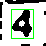

[0] area=1794.0, ar=1.00, fill=0.85, pos=(23,23)


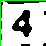

[1] area=1802.5, ar=1.00, fill=0.85, pos=(23,23)


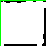

[2] area=230.0, ar=0.47, fill=0.55, pos=(20,23)


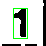

[2] area=1829.0, ar=0.96, fill=0.90, pos=(22,23)


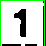

[3] area=1820.5, ar=1.00, fill=0.86, pos=(23,23)


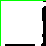

[4] area=505.5, ar=0.70, fill=0.67, pos=(20,22)


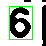

[4] area=1847.0, ar=1.00, fill=0.87, pos=(23,23)


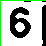

[5] area=1874.0, ar=0.93, fill=0.95, pos=(21,23)


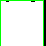

[6] area=394.5, ar=0.70, fill=0.52, pos=(20,22)


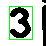

[6] area=1872.0, ar=1.00, fill=0.88, pos=(23,23)


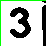

[7] area=1868.5, ar=1.00, fill=0.88, pos=(23,23)


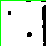

[8] area=395.5, ar=0.70, fill=0.52, pos=(20,23)


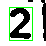

[8] area=1887.5, ar=1.00, fill=0.89, pos=(23,23)


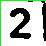

[9] area=299.5, ar=0.66, fill=0.45, pos=(21,21)


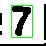

[9] area=1826.5, ar=1.05, fill=0.90, pos=(23,22)


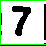

[10] area=1821.5, ar=1.05, fill=0.90, pos=(23,22)


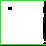

[11] area=1814.5, ar=0.93, fill=0.92, pos=(21,23)


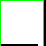

[12] area=375.5, ar=0.74, fill=0.53, pos=(19,21)


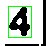

[12] area=1817.5, ar=0.93, fill=0.92, pos=(21,23)


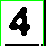

[13] area=1817.5, ar=0.96, fill=0.90, pos=(22,23)


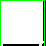

[14] area=402.0, ar=0.65, fill=0.54, pos=(21,22)


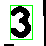

[14] area=1898.5, ar=0.96, fill=0.94, pos=(22,23)


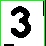

[15] area=1898.5, ar=0.96, fill=0.94, pos=(22,23)


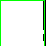

[16] area=1901.5, ar=0.96, fill=0.94, pos=(22,23)


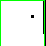

[17] area=242.5, ar=0.48, fill=0.52, pos=(19,23)


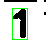

[17] area=1947.5, ar=1.00, fill=0.92, pos=(23,23)


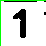

[18] area=1822.0, ar=1.05, fill=0.90, pos=(23,22)


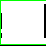

[19] area=1850.5, ar=1.05, fill=0.91, pos=(23,22)


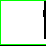

[20] area=1845.0, ar=0.96, fill=0.91, pos=(22,23)


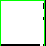

[21] area=1869.0, ar=1.00, fill=0.88, pos=(23,23)


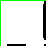

[22] area=524.0, ar=0.68, fill=0.67, pos=(20,22)


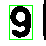

[22] area=1913.5, ar=1.00, fill=0.90, pos=(23,23)


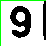

[23] area=1943.5, ar=1.00, fill=0.92, pos=(23,23)


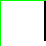

[24] area=1944.0, ar=1.00, fill=0.92, pos=(23,23)


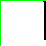

[25] area=1915.5, ar=1.00, fill=0.91, pos=(23,23)


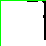

[26] area=1966.5, ar=1.00, fill=0.93, pos=(23,23)


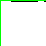

[27] area=1780.5, ar=1.00, fill=0.84, pos=(23,23)


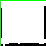

[28] area=1860.5, ar=1.05, fill=0.92, pos=(23,22)


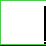

[29] area=300.0, ar=0.66, fill=0.45, pos=(21,21)


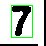

[29] area=1859.5, ar=0.96, fill=0.92, pos=(22,23)


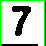

[30] area=436.5, ar=0.68, fill=0.56, pos=(21,22)


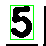

[30] area=1879.0, ar=1.00, fill=0.89, pos=(23,23)


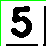

[31] area=1937.0, ar=1.00, fill=0.92, pos=(23,23)


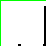

[32] area=241.5, ar=0.48, fill=0.52, pos=(20,22)


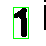

[32] area=1970.5, ar=1.00, fill=0.93, pos=(23,23)


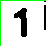

[33] area=372.0, ar=0.72, fill=0.51, pos=(20,23)


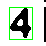

[33] area=1950.5, ar=1.00, fill=0.92, pos=(23,23)


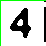

[34] area=1878.0, ar=1.00, fill=0.89, pos=(23,23)


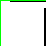

[35] area=1893.0, ar=1.05, fill=0.94, pos=(23,24)


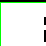

[36] area=1798.5, ar=1.05, fill=0.89, pos=(23,22)


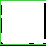

[37] area=1849.0, ar=1.05, fill=0.91, pos=(23,22)


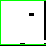

[38] area=510.5, ar=0.67, fill=0.70, pos=(22,21)


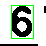

[38] area=1934.5, ar=1.00, fill=0.91, pos=(23,23)


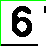

[39] area=1900.5, ar=1.00, fill=0.90, pos=(23,23)


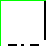

[40] area=1944.5, ar=1.00, fill=0.92, pos=(23,23)


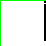

[41] area=2025.0, ar=1.00, fill=0.96, pos=(23,23)


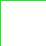

[42] area=427.0, ar=0.65, fill=0.57, pos=(22,23)


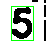

[42] area=1938.5, ar=1.00, fill=0.92, pos=(23,23)


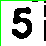

[43] area=1871.5, ar=1.00, fill=0.88, pos=(23,23)


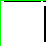

[44] area=1908.0, ar=1.00, fill=0.90, pos=(23,23)


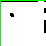

[45] area=1864.0, ar=1.05, fill=0.92, pos=(23,22)


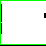

[46] area=1918.0, ar=1.05, fill=0.95, pos=(23,22)


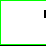

[47] area=393.0, ar=0.67, fill=0.54, pos=(23,21)


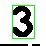

[47] area=1952.5, ar=1.00, fill=0.92, pos=(23,23)


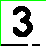

[48] area=521.5, ar=0.68, fill=0.67, pos=(22,22)


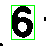

[48] area=2009.0, ar=1.00, fill=0.95, pos=(23,23)


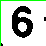

[49] area=2025.0, ar=1.00, fill=0.96, pos=(23,23)


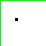

[50] area=408.5, ar=0.67, fill=0.56, pos=(22,22)


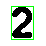

[50] area=2025.0, ar=1.00, fill=0.96, pos=(23,23)


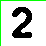

[51] area=303.0, ar=0.67, fill=0.42, pos=(22,22)


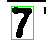

[51] area=1932.5, ar=1.00, fill=0.91, pos=(23,23)


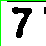

[52] area=1884.0, ar=1.00, fill=0.89, pos=(23,23)


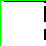

[53] area=1924.0, ar=1.00, fill=0.91, pos=(23,23)


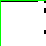

[54] area=1888.0, ar=1.00, fill=0.89, pos=(23,23)


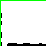

[55] area=1874.0, ar=1.05, fill=0.93, pos=(23,22)


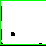

[56] area=1873.5, ar=1.00, fill=0.89, pos=(23,23)


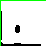

[57] area=1866.5, ar=1.00, fill=0.88, pos=(23,23)


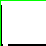

[58] area=245.0, ar=0.48, fill=0.53, pos=(21,22)


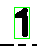

[58] area=1969.5, ar=1.00, fill=0.93, pos=(23,23)


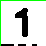

[59] area=1994.0, ar=1.00, fill=0.94, pos=(23,23)


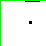

[60] area=1859.0, ar=1.00, fill=0.88, pos=(23,23)


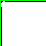

[61] area=1920.0, ar=1.05, fill=0.95, pos=(23,24)


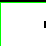

[62] area=1935.0, ar=1.05, fill=0.96, pos=(23,24)


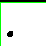

[63] area=515.0, ar=0.65, fill=0.69, pos=(24,21)


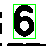

[63] area=1877.0, ar=1.00, fill=0.89, pos=(23,23)


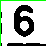

[64] area=1802.5, ar=1.00, fill=0.93, pos=(24,22)


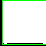

[65] area=1808.5, ar=1.00, fill=0.85, pos=(23,23)


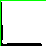

[66] area=392.0, ar=0.67, fill=0.54, pos=(24,21)


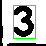

[66] area=1816.0, ar=0.96, fill=0.90, pos=(24,23)


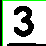

[67] area=1884.0, ar=1.00, fill=0.89, pos=(23,23)


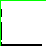

[68] area=361.0, ar=0.68, fill=0.55, pos=(21,22)


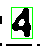

[68] area=1942.5, ar=1.00, fill=0.92, pos=(23,23)


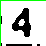

[69] area=1915.0, ar=0.96, fill=0.95, pos=(24,23)


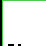

[70] area=1950.0, ar=1.00, fill=0.92, pos=(23,23)


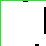

[71] area=297.0, ar=0.66, fill=0.44, pos=(21,22)


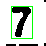

[71] area=1956.0, ar=1.00, fill=0.92, pos=(23,23)


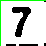

[72] area=243.5, ar=0.47, fill=0.51, pos=(23,21)


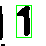

[72] area=1923.0, ar=1.00, fill=0.91, pos=(23,23)


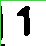

[73] area=1896.0, ar=1.00, fill=0.90, pos=(23,23)


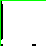

[74] area=544.0, ar=0.70, fill=0.72, pos=(24,20)


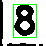

[74] area=1819.5, ar=0.96, fill=0.90, pos=(24,23)


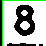

[75] area=1831.5, ar=0.96, fill=0.90, pos=(24,23)


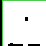

[76] area=420.0, ar=0.67, fill=0.58, pos=(24,21)


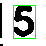

[76] area=1948.5, ar=1.00, fill=0.92, pos=(23,23)


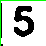

[77] area=1945.5, ar=1.00, fill=0.92, pos=(23,23)


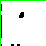

[78] area=506.0, ar=0.67, fill=0.70, pos=(23,21)


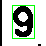

[78] area=1928.0, ar=0.96, fill=0.95, pos=(24,23)


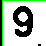

[79] area=1955.5, ar=1.00, fill=0.92, pos=(23,23)


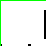

[80] area=351.5, ar=0.70, fill=0.56, pos=(20,21)


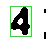

[80] area=2001.0, ar=1.00, fill=0.95, pos=(23,23)


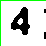

In [31]:
cells_new = []
for idx, cell in enumerate(cells):
  detected, celly = detect_digit_debug_with_median_and_close(cell, idx)
  cells_new.append(celly)

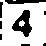

Cell 0 has a digit.


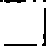

Cell 1 is EMPTY.


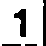

Cell 2 has a digit.


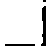

Cell 3 is EMPTY.


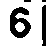

Cell 4 has a digit.


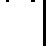

Cell 5 is EMPTY.


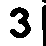

Cell 6 has a digit.


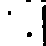

Cell 7 is EMPTY.


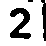

Cell 8 has a digit.


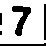

Cell 9 has a digit.


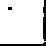

Cell 10 is EMPTY.


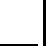

Cell 11 is EMPTY.


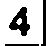

Cell 12 has a digit.


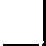

Cell 13 is EMPTY.


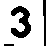

Cell 14 has a digit.


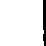

Cell 15 is EMPTY.


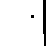

Cell 16 is EMPTY.


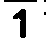

Cell 17 has a digit.


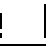

Cell 18 is EMPTY.


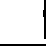

Cell 19 is EMPTY.


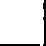

Cell 20 is EMPTY.


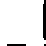

Cell 21 is EMPTY.


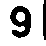

Cell 22 has a digit.


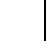

Cell 23 is EMPTY.


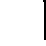

Cell 24 is EMPTY.


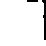

Cell 25 is EMPTY.


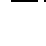

Cell 26 is EMPTY.


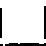

Cell 27 is EMPTY.


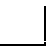

Cell 28 is EMPTY.


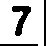

Cell 29 has a digit.


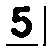

Cell 30 has a digit.


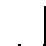

Cell 31 is EMPTY.


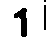

Cell 32 has a digit.


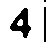

Cell 33 has a digit.


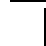

Cell 34 is EMPTY.


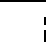

Cell 35 is EMPTY.


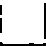

Cell 36 is EMPTY.


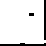

Cell 37 is EMPTY.


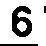

Cell 38 has a digit.


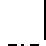

Cell 39 is EMPTY.


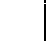

Cell 40 is EMPTY.


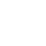

Cell 41 is EMPTY.


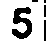

Cell 42 has a digit.


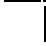

Cell 43 is EMPTY.


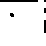

Cell 44 is EMPTY.


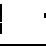

Cell 45 is EMPTY.


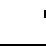

Cell 46 is EMPTY.


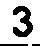

Cell 47 has a digit.


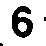

Cell 48 has a digit.


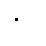

Cell 49 is EMPTY.


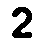

Cell 50 has a digit.


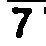

Cell 51 has a digit.


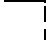

Cell 52 is EMPTY.


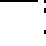

Cell 53 is EMPTY.


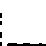

Cell 54 is EMPTY.


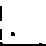

Cell 55 is EMPTY.


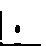

Cell 56 is EMPTY.


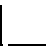

Cell 57 is EMPTY.


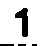

Cell 58 has a digit.


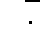

Cell 59 is EMPTY.


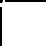

Cell 60 is EMPTY.


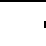

Cell 61 is EMPTY.


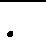

Cell 62 is EMPTY.


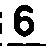

Cell 63 has a digit.


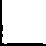

Cell 64 is EMPTY.


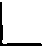

Cell 65 is EMPTY.


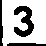

Cell 66 has a digit.


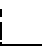

Cell 67 is EMPTY.


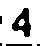

Cell 68 has a digit.


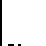

Cell 69 is EMPTY.


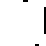

Cell 70 is EMPTY.


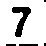

Cell 71 has a digit.


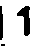

Cell 72 has a digit.


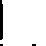

Cell 73 is EMPTY.


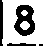

Cell 74 has a digit.


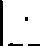

Cell 75 is EMPTY.


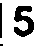

Cell 76 has a digit.


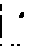

Cell 77 is EMPTY.


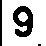

Cell 78 has a digit.


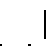

Cell 79 is EMPTY.


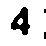

Cell 80 has a digit.


In [46]:

def is_digit_present(cell, idx=None):
    """
    Analyzes a cell and returns True if a digit is found,
    otherwise returns False.
    """
    if len(cell.shape) == 3:
        cell_gray = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
    else:
        cell_gray = cell

    h, w = cell_gray.shape

    # --- Preprocessing (as you had before) ---
    cell_blurred = cv2.medianBlur(cell_gray, 5)
    _, thresh = cv2.threshold(cell_blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((3,3), np.uint8)
    thresh_cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(thresh_cleaned, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return False # No contours found at all

    # --- Filtering Logic ---
    for c in contours:
        x, y, cw, ch = cv2.boundingRect(c)
        area = cv2.contourArea(c)

        # 1. Filter by Area
        # You must tune these min/max values by debugging
        MIN_AREA = 150
        MAX_AREA = (w * h) * 0.7  # Don't allow a contour > 70% of the cell
        if not (MIN_AREA < area < MAX_AREA):
            continue  # Not a digit, try next contour

        # 2. Filter by Aspect Ratio (width / height)
        aspect_ratio = cw / ch if ch > 0 else 0
        if not (0.1 < aspect_ratio < 1.5):
            continue  # Too skinny or too wide, probably a grid line

        # 3. Filter by Position (is it centered?)
        # Check if the contour's center (cx, cy) is in the
        # middle 80% of the cell.
        cx = x + cw // 2
        cy = y + ch // 2
        if not ((w * 0.1 < cx < w * 0.9) and (h * 0.1 < cy < h * 0.9)):
            continue # It's touching the extreme edge

        # --- If it passed all filters, it's a digit! ---
        # We can stop and return True immediately.

        # (Optional: print for final check)
        # print(f"[{idx}] FOUND DIGIT: area={area:.1f}, ar={aspect_ratio:.2f}")

        return True

    # If the loop finishes without finding any valid contour...
    return False


for i, cell in enumerate(cells_new):
    cv2_imshow(cell)
    if is_digit_present(cell, idx=i):
        print(f"Cell {i} has a digit.")
    else:
        print(f"Cell {i} is EMPTY.")

In [37]:
# Handwritten Digit Recognition using CNN
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# 1. Load and preprocess data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape to (28,28,1) because CNN expects a 3D input (H, W, Channels)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

# Normalize pixel values (0–255 → 0–1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels (0–9 → vector of size 10)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# 2. Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train model
history = model.fit(x_train, y_train, epochs=15, batch_size=64, validation_split=0.1)

# 5. Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# 6. Save model
model.save("cnn_mnist_model2.h5")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8801 - loss: 0.3973

KeyboardInterrupt: 

Using device: cuda
Model parameters: 943,978
Starting training...
Epoch: 1/15 | Batch: 0/469 | Loss: 2.6731
Epoch: 1/15 | Batch: 100/469 | Loss: 0.1809
Epoch: 1/15 | Batch: 200/469 | Loss: 0.0902
Epoch: 1/15 | Batch: 300/469 | Loss: 0.0764
Epoch: 1/15 | Batch: 400/469 | Loss: 0.0676
Epoch 1 Summary:
Training Loss: 0.1384 | Training Accuracy: 96.24%
--------------------------------------------------
Epoch: 2/15 | Batch: 0/469 | Loss: 0.0474
Epoch: 2/15 | Batch: 100/469 | Loss: 0.0687
Epoch: 2/15 | Batch: 200/469 | Loss: 0.0554
Epoch: 2/15 | Batch: 300/469 | Loss: 0.0879
Epoch: 2/15 | Batch: 400/469 | Loss: 0.0267
Epoch 2 Summary:
Training Loss: 0.0485 | Training Accuracy: 98.61%
--------------------------------------------------
Epoch: 3/15 | Batch: 0/469 | Loss: 0.0202
Epoch: 3/15 | Batch: 100/469 | Loss: 0.0132
Epoch: 3/15 | Batch: 200/469 | Loss: 0.0371
Epoch: 3/15 | Batch: 300/469 | Loss: 0.0328
Epoch: 3/15 | Batch: 400/469 | Loss: 0.0128
Epoch 3 Summary:
Training Loss: 0.0360 | Tra

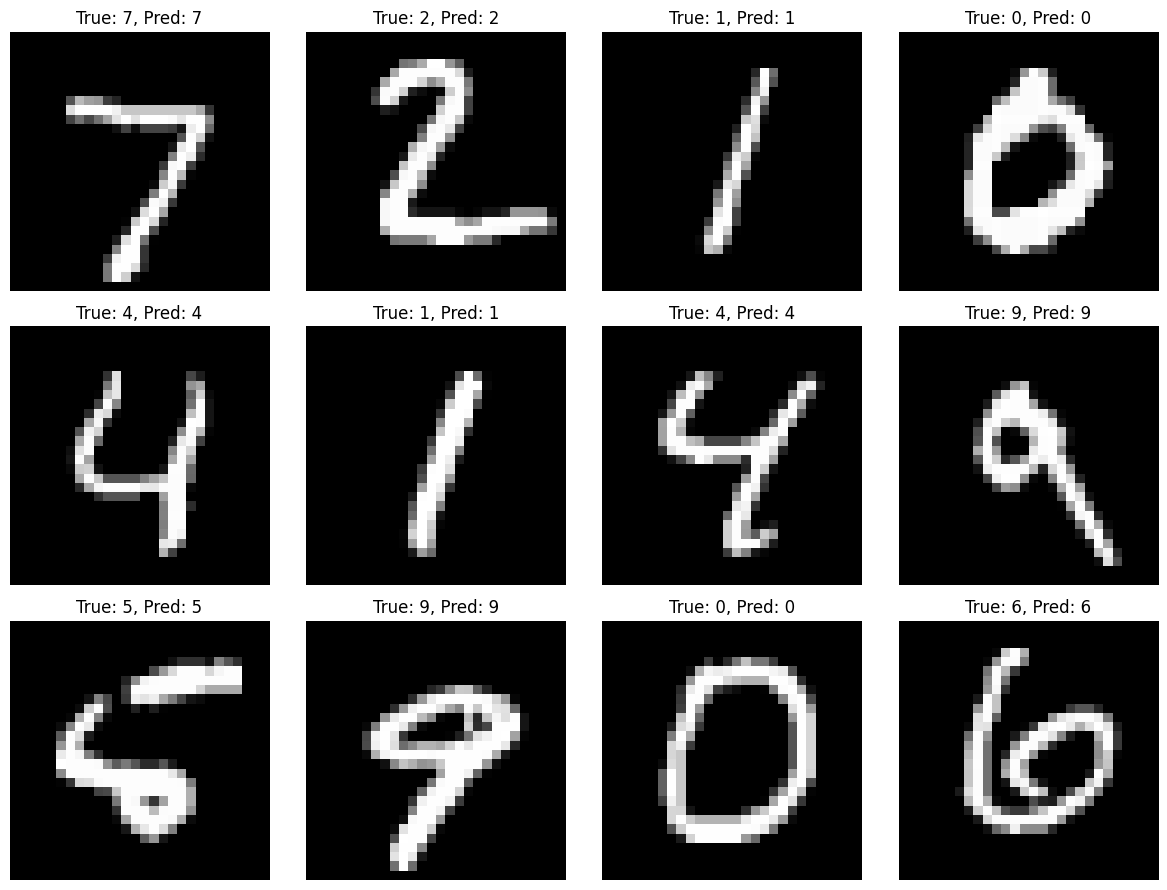

Model saved as 'digit_cnn_cuda.pth'


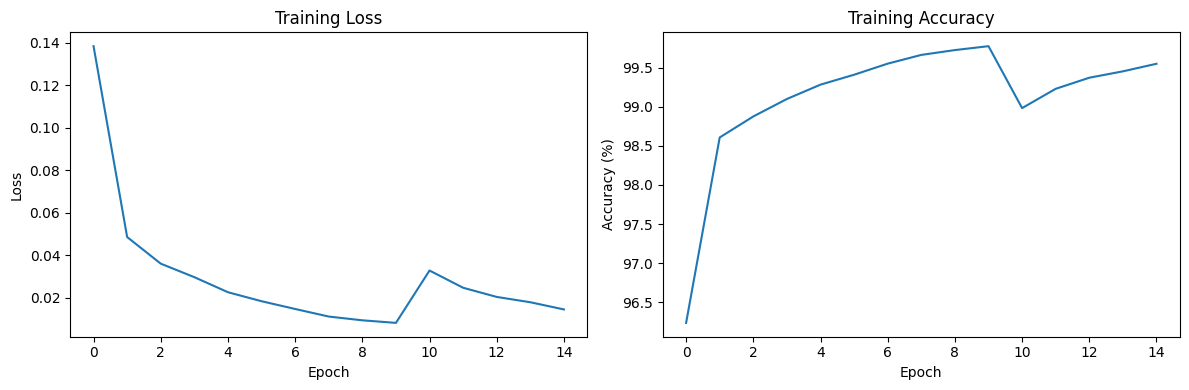

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
batch_size = 128
learning_rate = 0.001
num_epochs = 15

# Data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=2
)

# CNN Model
class DigitRecognizer(nn.Module):
    def __init__(self):
        super(DigitRecognizer, self).__init__()
        self.conv_layers = nn.Sequential(
            # First conv block
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Second conv block
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Third conv block
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.classifier(x)
        return x

# Initialize model
model = DigitRecognizer().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,           # Number of epochs for first restart cycle
    T_mult=2,         # Multiply T_0 by this after each restart
    eta_min=1e-6
)

# Training function
def train_model():
    train_losses, train_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            if batch_idx % 100 == 0:
                print(f'Epoch: {epoch+1}/{num_epochs} | '
                      f'Batch: {batch_idx}/{len(train_loader)} | '
                      f'Loss: {loss.item():.4f}')

        scheduler.step()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        print(f'Epoch {epoch+1} Summary:')
        print(f'Training Loss: {epoch_loss:.4f} | Training Accuracy: {epoch_acc:.2f}%')
        print('-' * 50)

    return train_losses, train_accs

# Evaluation function
def evaluate_model():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    accuracy = 100. * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')
    return accuracy

# Visualize predictions
def visualize_predictions(num_images=12):
    model.eval()
    with torch.no_grad():
        dataiter = iter(test_loader)
        images, labels = next(dataiter)
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = outputs.max(1)

        images = images.cpu().numpy()

        fig, axes = plt.subplots(3, 4, figsize=(12, 9))
        for i, ax in enumerate(axes.flat):
            ax.imshow(images[i].squeeze(), cmap='gray')
            ax.set_title(f'True: {labels[i].item()}, Pred: {predicted[i].item()}')
            ax.axis('off')
        plt.tight_layout()
        plt.show()

# Main execution
if __name__ == "__main__":
    print("Starting training...")
    train_losses, train_accs = train_model()

    print("\nEvaluating on test set...")
    test_accuracy = evaluate_model()

    print("\nVisualizing predictions...")
    visualize_predictions()

    # Save model
    torch.save(model.state_dict(), 'digit_cnn_cuda.pth')
    print("Model saved as 'digit_cnn_cuda.pth'")

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.subplot(1, 2, 2)
    plt.plot(train_accs)
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.tight_layout()
    plt.show()

In [39]:

image_path="/content/dataset/1.png"
img = image.load_img(image_path, color_mode='grayscale', target_size=(28, 28))
img = np.array(img).reshape(1, 28, 28, 1).astype('float32') / 255.0

prediction = model.predict(img)
print("Predicted digit:", np.argmax(prediction))


NameError: name 'image' is not defined

In [49]:
import cv2
import torch
import numpy as np
from PIL import Image

# Load your trained PyTorch model
model = DigitRecognizer()
model.load_state_dict(torch.load('digit_cnn_cuda.pth'))
model.to(device)
model.eval()  # Set to evaluation mode

def preprocessing(cell):
    """Enhanced preprocessing for real-world digit images"""
    if len(cell.shape) == 3:
        cell_gray = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
    else:
        cell_gray = cell

    # Resize
    img = cv2.resize(cell_gray, (28, 28))

    # Apply aggressive thresholding to get clean binary image
    _, img_binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert if needed (MNIST expects white digit on black background)
    if np.mean(img_binary) > 127:  # If mostly white
        img_binary = 255 - img_binary

    # Center the digit using moments (like MNIST)
    img_centered = center_digit(img_binary)

    # Normalize like MNIST training data
    img_normalized = img_centered.astype('float32') / 255.0
    img_normalized = (img_normalized - 0.1307) / 0.3081

    # Add batch and channel dimensions for PyTorch
    img_tensor = torch.FloatTensor(img_normalized).unsqueeze(0).unsqueeze(0)

    return img_tensor.to(device)

def center_digit(img):
    """Center the digit in the 28x28 image using moments"""
    # Find contours
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return img

    # Get largest contour (the digit)
    largest_contour = max(contours, key=cv2.contourArea)

    # Get bounding rect
    x, y, w, h = cv2.boundingRect(largest_contour)

    # Extract digit region
    digit_region = img[y:y+h, x:x+w]

    # Calculate padding to center
    pad_x = (28 - w) // 2
    pad_y = (28 - h) // 2

    # Create centered image
    centered = np.zeros((28, 28), dtype=np.uint8)
    centered[pad_y:pad_y+h, pad_x:pad_x+w] = digit_region

    return centered

# Your original loop adapted for PyTorch
for i, cell in enumerate(cells):
    if is_digit_present(cell):
        # Preprocess for PyTorch
        img_tensor = preprocessing(cell)

        # Show the image (optional)
        img_display = cv2.resize(cell, (28, 28))
        if len(img_display.shape) == 3:
            img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2GRAY)
        cv2_imshow(img_display)

        # Prediction
        with torch.no_grad():
            output = model(img_tensor)
            prediction = torch.softmax(output, dim=1)
            predicted_digit = torch.argmax(prediction, dim=1).item()
            confidence = torch.max(prediction).item()

        print(f"Cell {i}: Predicted Digit = {predicted_digit} (Confidence: {confidence:.2f})")

Cell 0: Predicted Digit = 4 (Confidence: 1.00)


Cell 2: Predicted Digit = 1 (Confidence: 0.97)


Cell 4: Predicted Digit = 6 (Confidence: 0.50)


Cell 6: Predicted Digit = 3 (Confidence: 1.00)


Cell 8: Predicted Digit = 2 (Confidence: 1.00)


Cell 9: Predicted Digit = 1 (Confidence: 0.84)


Cell 12: Predicted Digit = 4 (Confidence: 1.00)


Cell 14: Predicted Digit = 3 (Confidence: 1.00)


Cell 17: Predicted Digit = 1 (Confidence: 0.71)


Cell 22: Predicted Digit = 9 (Confidence: 0.99)


Cell 29: Predicted Digit = 1 (Confidence: 0.61)


Cell 30: Predicted Digit = 5 (Confidence: 1.00)


Cell 32: Predicted Digit = 1 (Confidence: 0.66)


Cell 33: Predicted Digit = 4 (Confidence: 1.00)


Cell 38: Predicted Digit = 6 (Confidence: 0.71)


Cell 42: Predicted Digit = 5 (Confidence: 1.00)


Cell 47: Predicted Digit = 3 (Confidence: 1.00)


Cell 48: Predicted Digit = 6 (Confidence: 0.93)


Cell 50: Predicted Digit = 2 (Confidence: 1.00)


Cell 51: Predicted Digit = 7 (Confidence: 0.94)


Cell 58: Predicted Digit = 1 (Confidence: 0.90)


Cell 63: Predicted Digit = 5 (Confidence: 0.55)


Cell 66: Predicted Digit = 3 (Confidence: 1.00)


Cell 68: Predicted Digit = 4 (Confidence: 0.99)


Cell 71: Predicted Digit = 2 (Confidence: 0.95)


Cell 72: Predicted Digit = 1 (Confidence: 0.74)


Cell 74: Predicted Digit = 8 (Confidence: 1.00)


Cell 76: Predicted Digit = 5 (Confidence: 1.00)


Cell 78: Predicted Digit = 9 (Confidence: 0.98)


Cell 80: Predicted Digit = 4 (Confidence: 1.00)


In [50]:

# Your original loop adapted for PyTorch
for i, cell in enumerate(cells_new):
    if is_digit_present(cell):
        # Preprocess for PyTorch
        img_tensor = preprocessing(cell)

        # Show the image (optional)
        img_display = cv2.resize(cell, (28, 28))
        if len(img_display.shape) == 3:
            img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2GRAY)
        cv2_imshow(img_display)

        # Prediction
        with torch.no_grad():
            output = model(img_tensor)
            prediction = torch.softmax(output, dim=1)
            predicted_digit = torch.argmax(prediction, dim=1).item()
            confidence = torch.max(prediction).item()

        print(f"Cell {i}: Predicted Digit = {predicted_digit} (Confidence: {confidence:.2f})")

Cell 0: Predicted Digit = 4 (Confidence: 1.00)


Cell 2: Predicted Digit = 1 (Confidence: 1.00)


Cell 4: Predicted Digit = 5 (Confidence: 0.58)


Cell 6: Predicted Digit = 3 (Confidence: 1.00)


Cell 8: Predicted Digit = 2 (Confidence: 1.00)


Cell 9: Predicted Digit = 7 (Confidence: 0.89)


Cell 12: Predicted Digit = 4 (Confidence: 1.00)


Cell 14: Predicted Digit = 3 (Confidence: 1.00)


Cell 17: Predicted Digit = 1 (Confidence: 0.67)


Cell 22: Predicted Digit = 9 (Confidence: 0.99)


Cell 29: Predicted Digit = 7 (Confidence: 0.78)


Cell 30: Predicted Digit = 5 (Confidence: 1.00)


Cell 32: Predicted Digit = 1 (Confidence: 1.00)


Cell 33: Predicted Digit = 4 (Confidence: 0.99)


Cell 38: Predicted Digit = 6 (Confidence: 0.95)


Cell 42: Predicted Digit = 5 (Confidence: 1.00)


Cell 47: Predicted Digit = 3 (Confidence: 1.00)


Cell 48: Predicted Digit = 6 (Confidence: 0.97)


Cell 50: Predicted Digit = 2 (Confidence: 1.00)


Cell 51: Predicted Digit = 7 (Confidence: 0.97)


Cell 58: Predicted Digit = 1 (Confidence: 0.97)


Cell 63: Predicted Digit = 6 (Confidence: 0.75)


Cell 66: Predicted Digit = 3 (Confidence: 1.00)


Cell 68: Predicted Digit = 4 (Confidence: 1.00)


Cell 71: Predicted Digit = 7 (Confidence: 0.58)


Cell 72: Predicted Digit = 1 (Confidence: 0.69)


Cell 74: Predicted Digit = 8 (Confidence: 1.00)


Cell 76: Predicted Digit = 5 (Confidence: 1.00)


Cell 78: Predicted Digit = 9 (Confidence: 0.99)


Cell 80: Predicted Digit = 4 (Confidence: 0.82)


/content/Sudoku_Dataset/sudoku2.jpg


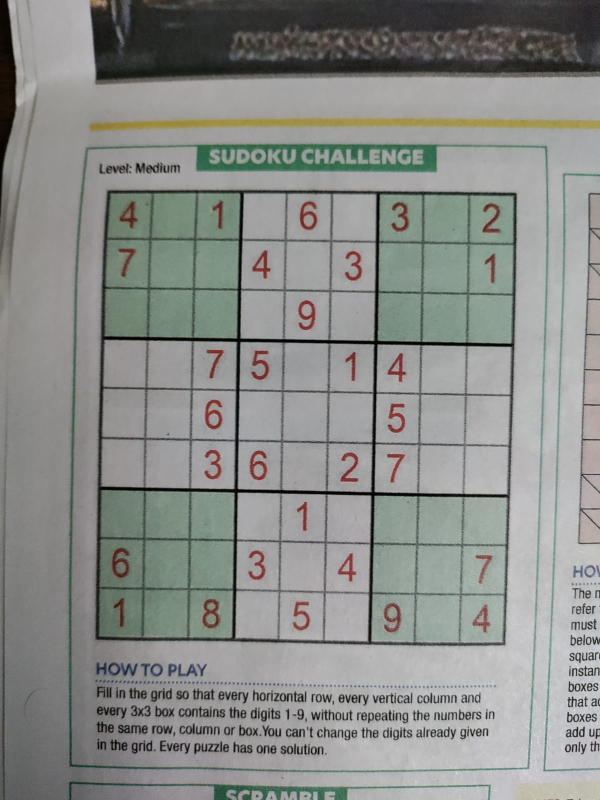

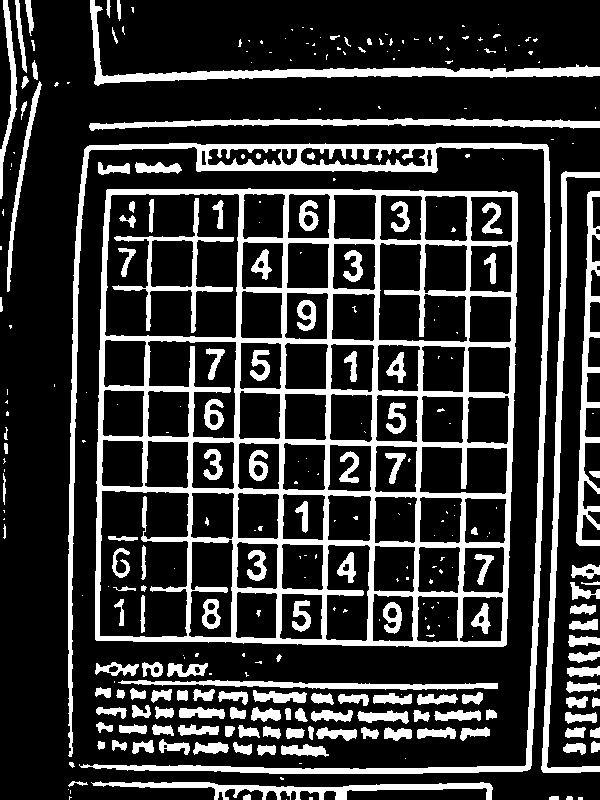

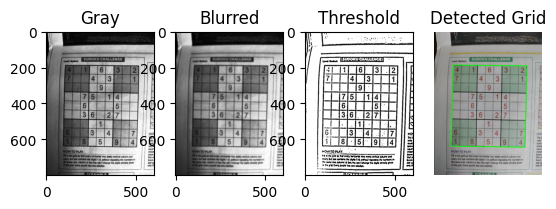

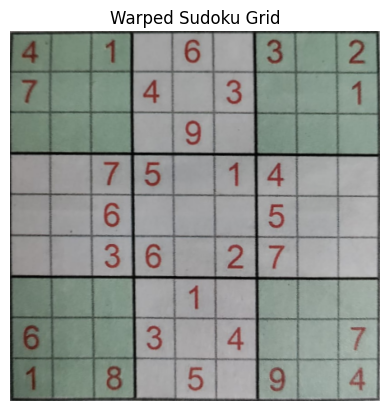

📷 Gray


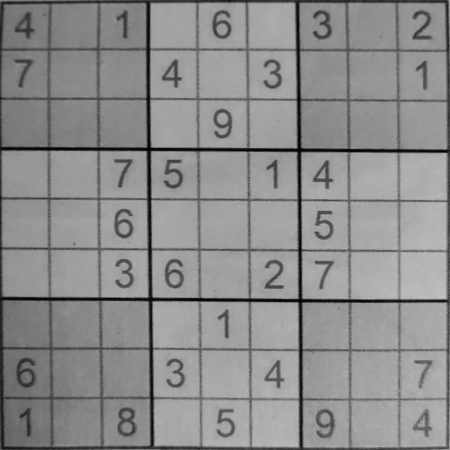

📷 Equalized


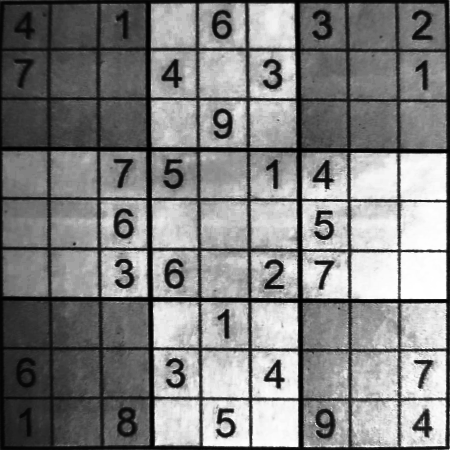

📷 Blurred


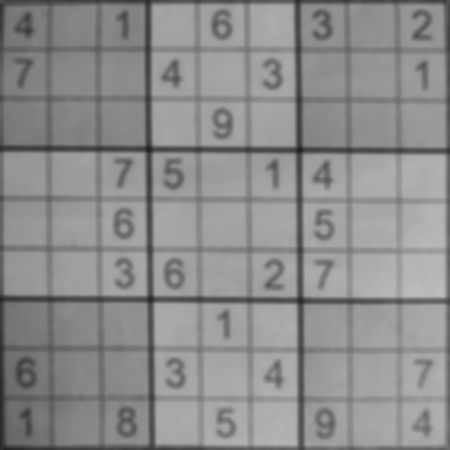

📷 Thresholded


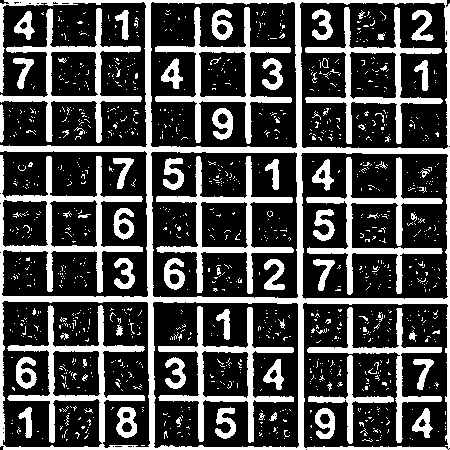

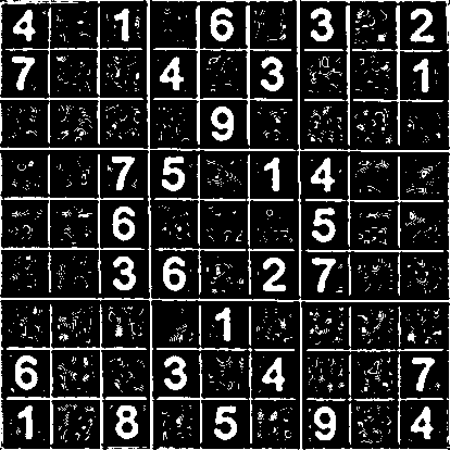

Extracted 81 cells


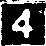

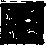

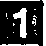

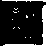

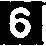

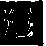

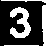

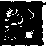

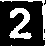

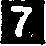

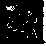

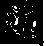

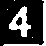

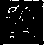

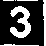

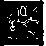

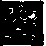

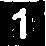

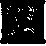

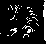

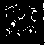

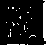

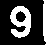

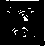

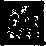

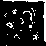

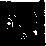

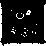

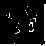

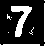

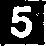

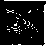

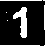

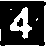

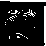

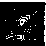

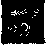

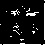

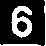

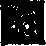

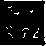

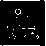

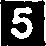

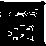

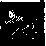

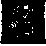

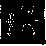

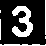

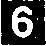

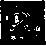

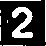

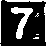

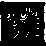

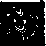

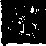

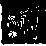

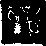

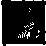

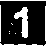

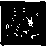

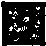

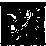

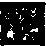

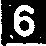

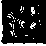

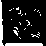

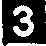

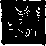

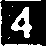

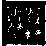

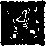

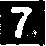

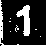

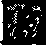

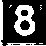

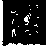

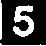

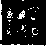

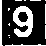

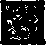

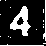

[0] area=342.5, ar=0.76, fill=0.54, pos=(22,23)


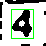

[0] area=1794.0, ar=1.00, fill=0.85, pos=(23,23)


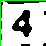

[1] area=1802.5, ar=1.00, fill=0.85, pos=(23,23)


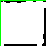

[2] area=230.0, ar=0.47, fill=0.55, pos=(20,23)


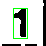

[2] area=1829.0, ar=0.96, fill=0.90, pos=(22,23)


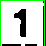

[3] area=1820.5, ar=1.00, fill=0.86, pos=(23,23)


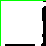

[4] area=505.5, ar=0.70, fill=0.67, pos=(20,22)


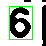

[4] area=1847.0, ar=1.00, fill=0.87, pos=(23,23)


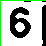

[5] area=1874.0, ar=0.93, fill=0.95, pos=(21,23)


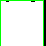

[6] area=394.5, ar=0.70, fill=0.52, pos=(20,22)


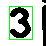

[6] area=1872.0, ar=1.00, fill=0.88, pos=(23,23)


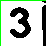

[7] area=1868.5, ar=1.00, fill=0.88, pos=(23,23)


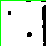

[8] area=395.5, ar=0.70, fill=0.52, pos=(20,23)


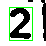

[8] area=1887.5, ar=1.00, fill=0.89, pos=(23,23)


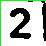

[9] area=299.5, ar=0.66, fill=0.45, pos=(21,21)


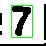

[9] area=1826.5, ar=1.05, fill=0.90, pos=(23,22)


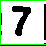

[10] area=1821.5, ar=1.05, fill=0.90, pos=(23,22)


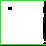

[11] area=1814.5, ar=0.93, fill=0.92, pos=(21,23)


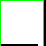

[12] area=375.5, ar=0.74, fill=0.53, pos=(19,21)


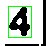

[12] area=1817.5, ar=0.93, fill=0.92, pos=(21,23)


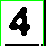

[13] area=1817.5, ar=0.96, fill=0.90, pos=(22,23)


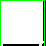

[14] area=402.0, ar=0.65, fill=0.54, pos=(21,22)


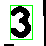

[14] area=1898.5, ar=0.96, fill=0.94, pos=(22,23)


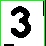

[15] area=1898.5, ar=0.96, fill=0.94, pos=(22,23)


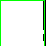

[16] area=1901.5, ar=0.96, fill=0.94, pos=(22,23)


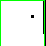

[17] area=242.5, ar=0.48, fill=0.52, pos=(19,23)


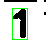

[17] area=1947.5, ar=1.00, fill=0.92, pos=(23,23)


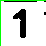

[18] area=1822.0, ar=1.05, fill=0.90, pos=(23,22)


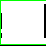

[19] area=1850.5, ar=1.05, fill=0.91, pos=(23,22)


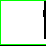

[20] area=1845.0, ar=0.96, fill=0.91, pos=(22,23)


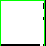

[21] area=1869.0, ar=1.00, fill=0.88, pos=(23,23)


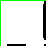

[22] area=524.0, ar=0.68, fill=0.67, pos=(20,22)


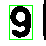

[22] area=1913.5, ar=1.00, fill=0.90, pos=(23,23)


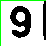

[23] area=1943.5, ar=1.00, fill=0.92, pos=(23,23)


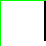

[24] area=1944.0, ar=1.00, fill=0.92, pos=(23,23)


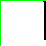

[25] area=1915.5, ar=1.00, fill=0.91, pos=(23,23)


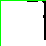

[26] area=1966.5, ar=1.00, fill=0.93, pos=(23,23)


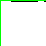

[27] area=1780.5, ar=1.00, fill=0.84, pos=(23,23)


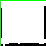

[28] area=1860.5, ar=1.05, fill=0.92, pos=(23,22)


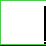

[29] area=300.0, ar=0.66, fill=0.45, pos=(21,21)


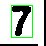

[29] area=1859.5, ar=0.96, fill=0.92, pos=(22,23)


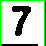

[30] area=436.5, ar=0.68, fill=0.56, pos=(21,22)


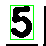

[30] area=1879.0, ar=1.00, fill=0.89, pos=(23,23)


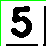

[31] area=1937.0, ar=1.00, fill=0.92, pos=(23,23)


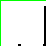

[32] area=241.5, ar=0.48, fill=0.52, pos=(20,22)


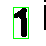

[32] area=1970.5, ar=1.00, fill=0.93, pos=(23,23)


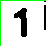

[33] area=372.0, ar=0.72, fill=0.51, pos=(20,23)


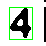

[33] area=1950.5, ar=1.00, fill=0.92, pos=(23,23)


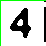

[34] area=1878.0, ar=1.00, fill=0.89, pos=(23,23)


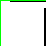

[35] area=1893.0, ar=1.05, fill=0.94, pos=(23,24)


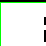

[36] area=1798.5, ar=1.05, fill=0.89, pos=(23,22)


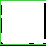

[37] area=1849.0, ar=1.05, fill=0.91, pos=(23,22)


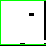

[38] area=510.5, ar=0.67, fill=0.70, pos=(22,21)


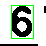

[38] area=1934.5, ar=1.00, fill=0.91, pos=(23,23)


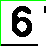

[39] area=1900.5, ar=1.00, fill=0.90, pos=(23,23)


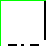

[40] area=1944.5, ar=1.00, fill=0.92, pos=(23,23)


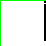

[41] area=2025.0, ar=1.00, fill=0.96, pos=(23,23)


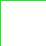

[42] area=427.0, ar=0.65, fill=0.57, pos=(22,23)


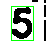

[42] area=1938.5, ar=1.00, fill=0.92, pos=(23,23)


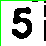

[43] area=1871.5, ar=1.00, fill=0.88, pos=(23,23)


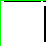

[44] area=1908.0, ar=1.00, fill=0.90, pos=(23,23)


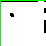

[45] area=1864.0, ar=1.05, fill=0.92, pos=(23,22)


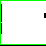

[46] area=1918.0, ar=1.05, fill=0.95, pos=(23,22)


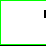

[47] area=393.0, ar=0.67, fill=0.54, pos=(23,21)


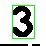

[47] area=1952.5, ar=1.00, fill=0.92, pos=(23,23)


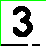

[48] area=521.5, ar=0.68, fill=0.67, pos=(22,22)


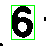

[48] area=2009.0, ar=1.00, fill=0.95, pos=(23,23)


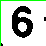

[49] area=2025.0, ar=1.00, fill=0.96, pos=(23,23)


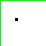

[50] area=408.5, ar=0.67, fill=0.56, pos=(22,22)


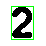

[50] area=2025.0, ar=1.00, fill=0.96, pos=(23,23)


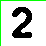

[51] area=303.0, ar=0.67, fill=0.42, pos=(22,22)


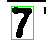

[51] area=1932.5, ar=1.00, fill=0.91, pos=(23,23)


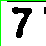

[52] area=1884.0, ar=1.00, fill=0.89, pos=(23,23)


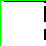

[53] area=1924.0, ar=1.00, fill=0.91, pos=(23,23)


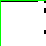

[54] area=1888.0, ar=1.00, fill=0.89, pos=(23,23)


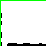

[55] area=1874.0, ar=1.05, fill=0.93, pos=(23,22)


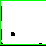

[56] area=1873.5, ar=1.00, fill=0.89, pos=(23,23)


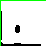

[57] area=1866.5, ar=1.00, fill=0.88, pos=(23,23)


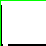

[58] area=245.0, ar=0.48, fill=0.53, pos=(21,22)


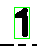

[58] area=1969.5, ar=1.00, fill=0.93, pos=(23,23)


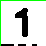

[59] area=1994.0, ar=1.00, fill=0.94, pos=(23,23)


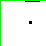

[60] area=1859.0, ar=1.00, fill=0.88, pos=(23,23)


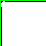

[61] area=1920.0, ar=1.05, fill=0.95, pos=(23,24)


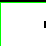

[62] area=1935.0, ar=1.05, fill=0.96, pos=(23,24)


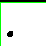

[63] area=515.0, ar=0.65, fill=0.69, pos=(24,21)


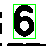

[63] area=1877.0, ar=1.00, fill=0.89, pos=(23,23)


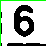

[64] area=1802.5, ar=1.00, fill=0.93, pos=(24,22)


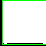

[65] area=1808.5, ar=1.00, fill=0.85, pos=(23,23)


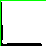

[66] area=392.0, ar=0.67, fill=0.54, pos=(24,21)


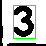

[66] area=1816.0, ar=0.96, fill=0.90, pos=(24,23)


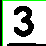

[67] area=1884.0, ar=1.00, fill=0.89, pos=(23,23)


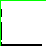

[68] area=361.0, ar=0.68, fill=0.55, pos=(21,22)


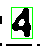

[68] area=1942.5, ar=1.00, fill=0.92, pos=(23,23)


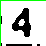

[69] area=1915.0, ar=0.96, fill=0.95, pos=(24,23)


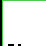

[70] area=1950.0, ar=1.00, fill=0.92, pos=(23,23)


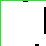

[71] area=297.0, ar=0.66, fill=0.44, pos=(21,22)


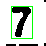

[71] area=1956.0, ar=1.00, fill=0.92, pos=(23,23)


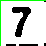

[72] area=243.5, ar=0.47, fill=0.51, pos=(23,21)


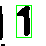

[72] area=1923.0, ar=1.00, fill=0.91, pos=(23,23)


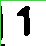

[73] area=1896.0, ar=1.00, fill=0.90, pos=(23,23)


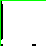

[74] area=544.0, ar=0.70, fill=0.72, pos=(24,20)


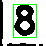

[74] area=1819.5, ar=0.96, fill=0.90, pos=(24,23)


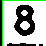

[75] area=1831.5, ar=0.96, fill=0.90, pos=(24,23)


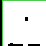

[76] area=420.0, ar=0.67, fill=0.58, pos=(24,21)


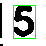

[76] area=1948.5, ar=1.00, fill=0.92, pos=(23,23)


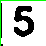

[77] area=1945.5, ar=1.00, fill=0.92, pos=(23,23)


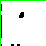

[78] area=506.0, ar=0.67, fill=0.70, pos=(23,21)


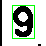

[78] area=1928.0, ar=0.96, fill=0.95, pos=(24,23)


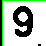

[79] area=1955.5, ar=1.00, fill=0.92, pos=(23,23)


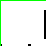

[80] area=351.5, ar=0.70, fill=0.56, pos=(20,21)


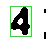

[80] area=2001.0, ar=1.00, fill=0.95, pos=(23,23)


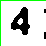

Using device: cuda


Cell 0: Predicted Digit = 4 (Confidence: 1.00)


Cell 2: Predicted Digit = 1 (Confidence: 1.00)


Cell 4: Predicted Digit = 5 (Confidence: 0.58)


Cell 6: Predicted Digit = 3 (Confidence: 1.00)


Cell 8: Predicted Digit = 2 (Confidence: 1.00)


Cell 9: Predicted Digit = 7 (Confidence: 0.89)


Cell 12: Predicted Digit = 4 (Confidence: 1.00)


Cell 14: Predicted Digit = 3 (Confidence: 1.00)


Cell 17: Predicted Digit = 1 (Confidence: 0.67)


Cell 22: Predicted Digit = 9 (Confidence: 0.99)


Cell 29: Predicted Digit = 7 (Confidence: 0.78)


Cell 30: Predicted Digit = 5 (Confidence: 1.00)


Cell 32: Predicted Digit = 1 (Confidence: 1.00)


Cell 33: Predicted Digit = 4 (Confidence: 0.99)


Cell 38: Predicted Digit = 6 (Confidence: 0.95)


Cell 42: Predicted Digit = 5 (Confidence: 1.00)


Cell 47: Predicted Digit = 3 (Confidence: 1.00)


Cell 48: Predicted Digit = 6 (Confidence: 0.97)


Cell 50: Predicted Digit = 2 (Confidence: 1.00)


Cell 51: Predicted Digit = 7 (Confidence: 0.97)


Cell 58: Predicted Digit = 1 (Confidence: 0.97)


Cell 63: Predicted Digit = 6 (Confidence: 0.75)


Cell 66: Predicted Digit = 3 (Confidence: 1.00)


Cell 68: Predicted Digit = 4 (Confidence: 1.00)


Cell 71: Predicted Digit = 7 (Confidence: 0.58)


Cell 72: Predicted Digit = 1 (Confidence: 0.69)


Cell 74: Predicted Digit = 8 (Confidence: 1.00)


Cell 76: Predicted Digit = 5 (Confidence: 1.00)


Cell 78: Predicted Digit = 9 (Confidence: 0.99)


Cell 80: Predicted Digit = 4 (Confidence: 0.82)
[4, 0, 1, 0, 5, 0, 3, 0, 2]
[7, 0, 0, 4, 0, 3, 0, 0, 1]
[0, 0, 0, 0, 9, 0, 0, 0, 0]
[0, 0, 7, 5, 0, 1, 4, 0, 0]
[0, 0, 6, 0, 0, 0, 5, 0, 0]
[0, 0, 3, 6, 0, 2, 7, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0, 0]
[6, 0, 0, 3, 0, 4, 0, 0, 7]
[1, 0, 8, 0, 5, 0, 9, 0, 4]


In [59]:
import cv2
import torch
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import cv2
from google.colab.patches import cv2_imshow  # ✅ required in Colab

import cv2
import numpy as np
from google.colab.patches import cv2_imshow  # ✅ Required for Colab display

import cv2
import imutils
import numpy as np
import matplotlib.pyplot as plt

from google.colab.patches import cv2_imshow

def convert_image_path(image_path):

    def preprocess_image(image, height):
        ##Resizing the image for smaller pixel sizes
        image=imutils.resize(image,height=height)
        ## Step 1: Converting to gray scale
        gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
        ## Step 1.1 : Histogram equalization to normalize contrast across the whole image
        gray=cv2.equalizeHist(gray)
        plt.subplot(1,4,1); plt.imshow(gray, cmap='gray'); plt.title("Gray")
        ## Step 2: Gaussing Blurring for noise reduction
        blurred = cv2.GaussianBlur(gray,(7,7),3,cv2.BORDER_REFLECT_101)
        plt.subplot(1,4,2); plt.imshow(blurred, cmap='gray'); plt.title("Blurred")
        ## Step 3: Adaptive Thresholding
        ## https://docs.opencv.org/3.4/d7/d4d/tutorial_py_thresholding.html
        thresh= cv2.adaptiveThreshold(
            blurred,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11,3
        )
        plt.subplot(1,4,3); plt.imshow(thresh, cmap='gray'); plt.title("Threshold")
        ## Step 4: Invert to make grid lines white
        thresh=cv2.bitwise_not(thresh)

        ## Step 5: Morphological op
        kernel=cv2.getStructuringElement(cv2.MORPH_RECT,(3,3))
        processed=cv2.morphologyEx(thresh,cv2.MORPH_CLOSE,kernel)

        plt.subplot(1,4,4); plt.imshow(processed, cmap='gray'); plt.title("Edges")
        return image,processed

    def preprocess(image_path,height=800):
        image=cv2.imread(image_path)
        return preprocess_image(image,height)

    print(image_path)
    # Check if the file exists
    if not os.path.exists(image_path):
        print("❌ Error: Image file not found at", image_path)

    original,processed=preprocess(image_path)
    cv2_imshow(original)
    cv2_imshow(processed)

    def order_points(pts):
        rect = np.zeros((4, 2), dtype="float32")
        s = pts.sum(axis=1)
        rect[0] = pts[np.argmin(s)]   # top-left has smallest sum
        rect[2] = pts[np.argmax(s)]   # bottom-right has largest sum

        diff = np.diff(pts, axis=1)
        rect[1] = pts[np.argmin(diff)]  # top-right has smallest difference
        rect[3] = pts[np.argmax(diff)]  # bottom-left has largest difference
        return rect

    def detect_sudoku_grid(processed,original_image):
        contours = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contours = imutils.grab_contours(contours)
        contours = sorted(contours, key=cv2.contourArea, reverse=True)

        sudoku_contour = None
        for c in contours:
            peri = cv2.arcLength(c, True)
            approx = cv2.approxPolyDP(c, 0.03 * peri, True)
            if len(approx) == 4:
                sudoku_contour = approx
                break

        if sudoku_contour is None:
            print("❌ Sudoku grid not found.")
            return None, None

        # Order corners
        sudoku_contour = sudoku_contour.reshape(4, 2)
        rect = order_points(sudoku_contour)

        # Draw contour for visualization
        debug_img = original_image.copy()
        cv2.drawContours(debug_img, [sudoku_contour.astype(int)], -1, (0, 255, 0), 3)

        return rect, debug_img

    rect, debug = detect_sudoku_grid(processed, original)
    plt.imshow(cv2.cvtColor(debug, cv2.COLOR_BGR2RGB))
    plt.title("Detected Grid")
    plt.axis('off')
    plt.show()

    def wrap_sudoku(order_points,original_image):
        output_size=450
        dst = np.array([
                [0, 0],
                [output_size - 1, 0],
                [output_size - 1, output_size - 1],
                [0, output_size - 1]
            ], dtype="float32")
        M=cv2.getPerspectiveTransform(rect,dst)
        warped=cv2.warpPerspective(original_image,M,(output_size,output_size))
        return warped

    warped_image=wrap_sudoku(rect,original)
    plt.imshow(cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB))
    plt.title("Warped Sudoku Grid")
    plt.axis("off")
    plt.show()

    def preprocess_wrapped_sudoku(warped, show_steps=False):
        """
        Preprocess a warped Sudoku image for digit extraction.

        Steps:
        1. Convert to grayscale
        2. Histogram equalization
        3. Gaussian blur
        4. Adaptive thresholding (binary inverse)

        Parameters:
            warped (np.ndarray): Warped Sudoku image (top-down view)
            show_steps (bool): If True, displays intermediate steps

        Returns:
            thresh (np.ndarray): Final preprocessed (binary) image
            steps (dict): Dictionary of intermediate results
        """

        steps = {}

        # 1️⃣ Grayscale conversion
        gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY) if len(warped.shape) == 3 else warped
        steps["gray"] = gray

        # 2️⃣ Histogram equalization for better contrast
        gray_eq = cv2.equalizeHist(gray)
        steps["equalized"] = gray_eq

        # 3️⃣ Gaussian blur to reduce small noise
        blurred = cv2.GaussianBlur(gray,(7,7),3,cv2.BORDER_REFLECT_101)
        steps["blurred"] = blurred

        # 4️⃣ Adaptive threshold (invert so digits are white)
        thresh = cv2.adaptiveThreshold(
        blurred,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,11,1
        )
        steps["thresh"] = thresh

        # Optional visualization
        if show_steps:
            titles = ["Gray", "Equalized", "Blurred", "Thresholded"]
            images = [steps[k] for k in ["gray", "equalized", "blurred", "thresh"]]
            for title, img in zip(titles, images):
                print(f"📷 {title}")
                cv2_imshow(img)  # ✅ Show image in Colab

        return thresh, steps


    def split_into_cells(preprocessed_img, grid_size=9, visualize=False):
        """
        Splits a preprocessed Sudoku image into 81 individual cell images (9x9 grid).

        Parameters:
            preprocessed_img (np.ndarray): Binary (thresholded) top-down Sudoku image
            grid_size (int): Number of rows and columns (default 9)
            visualize (bool): If True, shows each cell in a grid visualization

        Returns:
            cells (list): List of 81 cell images (each as np.ndarray)
        """

        h, w = preprocessed_img.shape[:2]
        cell_h, cell_w = h // grid_size, w // grid_size

        cells = []

        for i in range(grid_size):
            for j in range(grid_size):
                # Crop each cell
                y1, y2 = i * cell_h, (i + 1) * cell_h
                x1, x2 = j * cell_w, (j + 1) * cell_w

                cell = preprocessed_img[y1:y2, x1:x2]

                # Optional cleanup (remove extra border pixels)
                margin = 2
                cell = cell[margin:-margin, margin:-margin] if cell.shape[0] > 4 and cell.shape[1] > 4 else cell

                cells.append(cell)

        # ✅ Visualization grid (only if requested)
        if visualize:
            cell_grid = np.zeros((h, w), dtype=np.uint8)
            idx = 0
            for i in range(grid_size):
                for j in range(grid_size):
                    y1, y2 = i * cell_h, (i + 1) * cell_h
                    x1, x2 = j * cell_w, (j + 1) * cell_w
                    cell_resized = cv2.resize(cells[idx], (cell_w, cell_h))
                    cell_grid[y1:y2, x1:x2] = cell_resized
                    idx += 1
            cv2_imshow(cell_grid)  # ✅ works in Colab

        return cells


    # Suppose `warped` is your top-down Sudoku image
    thresh, steps = preprocess_wrapped_sudoku(warped_image, show_steps=True)

    # Now split 'thresh' into 81 cells
    cells = split_into_cells(thresh,visualize=True)
    print(f"Extracted {len(cells)} cells")

    # Example: visualize one cell
    for cell in cells:
        cv2_imshow(cell)

    cells_new = []
    for idx, cell in enumerate(cells):
        detected, celly = detect_digit_debug_with_median_and_close(cell, idx)
        cells_new.append(celly)

    def is_digit_present(cell, idx=None):
        """
        Analyzes a cell and returns True if a digit is found,
        otherwise returns False.
        """
        if len(cell.shape) == 3:
            cell_gray = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
        else:
            cell_gray = cell

        h, w = cell_gray.shape

        # --- Preprocessing (as you had before) ---
        cell_blurred = cv2.medianBlur(cell_gray, 5)
        _, thresh = cv2.threshold(cell_blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        kernel = np.ones((3,3), np.uint8)
        thresh_cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

        contours, _ = cv2.findContours(thresh_cleaned, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) == 0:
            return False # No contours found at all

        # --- Filtering Logic ---
        for c in contours:
            x, y, cw, ch = cv2.boundingRect(c)
            area = cv2.contourArea(c)

            # 1. Filter by Area
            # You must tune these min/max values by debugging
            MIN_AREA = 150
            MAX_AREA = (w * h) * 0.7  # Don't allow a contour > 70% of the cell
            if not (MIN_AREA < area < MAX_AREA):
                continue  # Not a digit, try next contour

            # 2. Filter by Aspect Ratio (width / height)
            aspect_ratio = cw / ch if ch > 0 else 0
            if not (0.1 < aspect_ratio < 1.5):
                continue  # Too skinny or too wide, probably a grid line

            # 3. Filter by Position (is it centered?)
            # Check if the contour's center (cx, cy) is in the
            # middle 80% of the cell.
            cx = x + cw // 2
            cy = y + ch // 2
            if not ((w * 0.1 < cx < w * 0.9) and (h * 0.1 < cy < h * 0.9)):
                continue # It's touching the extreme edge

            # --- If it passed all filters, it's a digit! ---
            # We can stop and return True immediately.

            # (Optional: print for final check)
            # print(f"[{idx}] FOUND DIGIT: area={area:.1f}, ar={aspect_ratio:.2f}")

            return True

        # If the loop finishes without finding any valid contour...
        return False

    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Hyperparameters
    batch_size = 128
    learning_rate = 0.001
    num_epochs = 15

    # Data transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    # Load MNIST dataset
    train_dataset = torchvision.datasets.MNIST(
        root='./data', train=True, transform=transform, download=True
    )
    test_dataset = torchvision.datasets.MNIST(
        root='./data', train=False, transform=transform, download=True
    )

    train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
    )
    test_loader = torch.utils.data.DataLoader(
        dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    # CNN Model
    class DigitRecognizer(nn.Module):
        def __init__(self):
            super(DigitRecognizer, self).__init__()
            self.conv_layers = nn.Sequential(
                # First conv block
                nn.Conv2d(1, 32, 3, padding=1),
                nn.ReLU(),
                nn.BatchNorm2d(32),
                nn.Conv2d(32, 32, 3, padding=1),
                nn.ReLU(),
                nn.BatchNorm2d(32),
                nn.MaxPool2d(2),
                nn.Dropout(0.25),

                # Second conv block
                nn.Conv2d(32, 64, 3, padding=1),
                nn.ReLU(),
                nn.BatchNorm2d(64),
                nn.Conv2d(64, 64, 3, padding=1),
                nn.ReLU(),
                nn.BatchNorm2d(64),
                nn.MaxPool2d(2),
                nn.Dropout(0.25),

                # Third conv block
                nn.Conv2d(64, 128, 3, padding=1),
                nn.ReLU(),
                nn.BatchNorm2d(128),
                nn.Dropout(0.25)
            )

            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128 * 7 * 7, 128),
                nn.ReLU(),
                nn.BatchNorm1d(128),
                nn.Dropout(0.5),
                nn.Linear(128, 10)
            )

        def forward(self, x):
            x = self.conv_layers(x)
            x = self.classifier(x)
            return x

    # Load your trained PyTorch model
    model = DigitRecognizer()
    model.load_state_dict(torch.load('digit_cnn_cuda.pth'))
    model.to(device)
    model.eval()  # Set to evaluation mode

    def preprocessing(cell):
        """Enhanced preprocessing for real-world digit images"""
        if len(cell.shape) == 3:
            cell_gray = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
        else:
            cell_gray = cell

        # Resize
        img = cv2.resize(cell_gray, (28, 28))

        # Apply aggressive thresholding to get clean binary image
        _, img_binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Invert if needed (MNIST expects white digit on black background)
        if np.mean(img_binary) > 127:  # If mostly white
            img_binary = 255 - img_binary

        # Center the digit using moments (like MNIST)
        img_centered = center_digit(img_binary)

        # Normalize like MNIST training data
        img_normalized = img_centered.astype('float32') / 255.0
        img_normalized = (img_normalized - 0.1307) / 0.3081

        # Add batch and channel dimensions for PyTorch
        img_tensor = torch.FloatTensor(img_normalized).unsqueeze(0).unsqueeze(0)

        return img_tensor.to(device)

    def center_digit(img):
        """Center the digit in the 28x28 image using moments"""
        # Find contours
        contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            return img

        # Get largest contour (the digit)
        largest_contour = max(contours, key=cv2.contourArea)

        # Get bounding rect
        x, y, w, h = cv2.boundingRect(largest_contour)

        # Extract digit region
        digit_region = img[y:y+h, x:x+w]

        # Calculate padding to center
        pad_x = (28 - w) // 2
        pad_y = (28 - h) // 2

        # Create centered image
        centered = np.zeros((28, 28), dtype=np.uint8)
        centered[pad_y:pad_y+h, pad_x:pad_x+w] = digit_region

        return centered

    grid = [[0 for _ in range(9)] for _ in range(9)]

    # Your original loop adapted for PyTorch
    for i, cell in enumerate(cells_new):
        if is_digit_present(cell):
            # Preprocess for PyTorch
            img_tensor = preprocessing(cell)

            # Show the image (optional)
            img_display = cv2.resize(cell, (28, 28))
            if len(img_display.shape) == 3:
                img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2GRAY)
            cv2_imshow(img_display)

            # Prediction
            with torch.no_grad():
                output = model(img_tensor)
                prediction = torch.softmax(output, dim=1)
                predicted_digit = torch.argmax(prediction, dim=1).item()
                confidence = torch.max(prediction).item()

            grid[i // 9][i % 9] = predicted_digit

            print(f"Cell {i}: Predicted Digit = {predicted_digit} (Confidence: {confidence:.2f})")

    return grid


image_path = "/content/Sudoku_Dataset/sudoku2.jpg"
g = convert_image_path(image_path)
print(*g, sep='\n')